This notebook is used for testing the generalibility of the train model. The method is to train a model on one dataset and test it on the other.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import merge_feature as mf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
from stringdb_alias import HGNCMapper
import torch.optim as optim
import torch
import torch.nn as nn
from matplotlib.patches import Patch
from torch.utils.data import Dataset,DataLoader
import json
import random
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
def seed_everything(seed=123):
    """"
    Seed everything.
    """   
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

In [3]:
method = 'LogisticRegression'
lr_ppi_only_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_ppi_only.csv',index_col=0)
lr_st_relation_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_st_relation.csv',index_col=0)
lr_all_feature_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_all_features.csv',index_col = 0)
method = 'RandomForest'
rf_ppi_only_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_ppi_only.csv',index_col=0)
rf_st_relation_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_st_relation.csv',index_col=0)
rf_all_feature_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_all_features.csv',index_col = 0)
method = 'XGBoost'
xgb_ppi_only_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_ppi_only.csv',index_col=0)
xgb_st_relation_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_st_relation.csv',index_col=0)
xgb_all_feature_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_all_features.csv',index_col = 0)
method = 'NN'
nn_ppi_only_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_ppi_only.csv',index_col=0)
nn_st_relation_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_st_relation.csv',index_col=0)
nn_all_feature_auc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUROC_'+method+'_all_features.csv',index_col = 0)

Cholesterol homeostasis Cholesterol uptake
Cholesterol homeostasis Influenza A virus replication
Cholesterol homeostasis Mitochondrial protein abundance
Cholesterol uptake Cholesterol homeostasis
Cholesterol uptake Influenza A virus replication
Cholesterol uptake Mitochondrial protein abundance
Influenza A virus replication Cholesterol homeostasis
Influenza A virus replication Cholesterol uptake
Influenza A virus replication Mitochondrial protein abundance
Mitochondrial protein abundance Cholesterol homeostasis
Mitochondrial protein abundance Cholesterol uptake
Mitochondrial protein abundance Influenza A virus replication


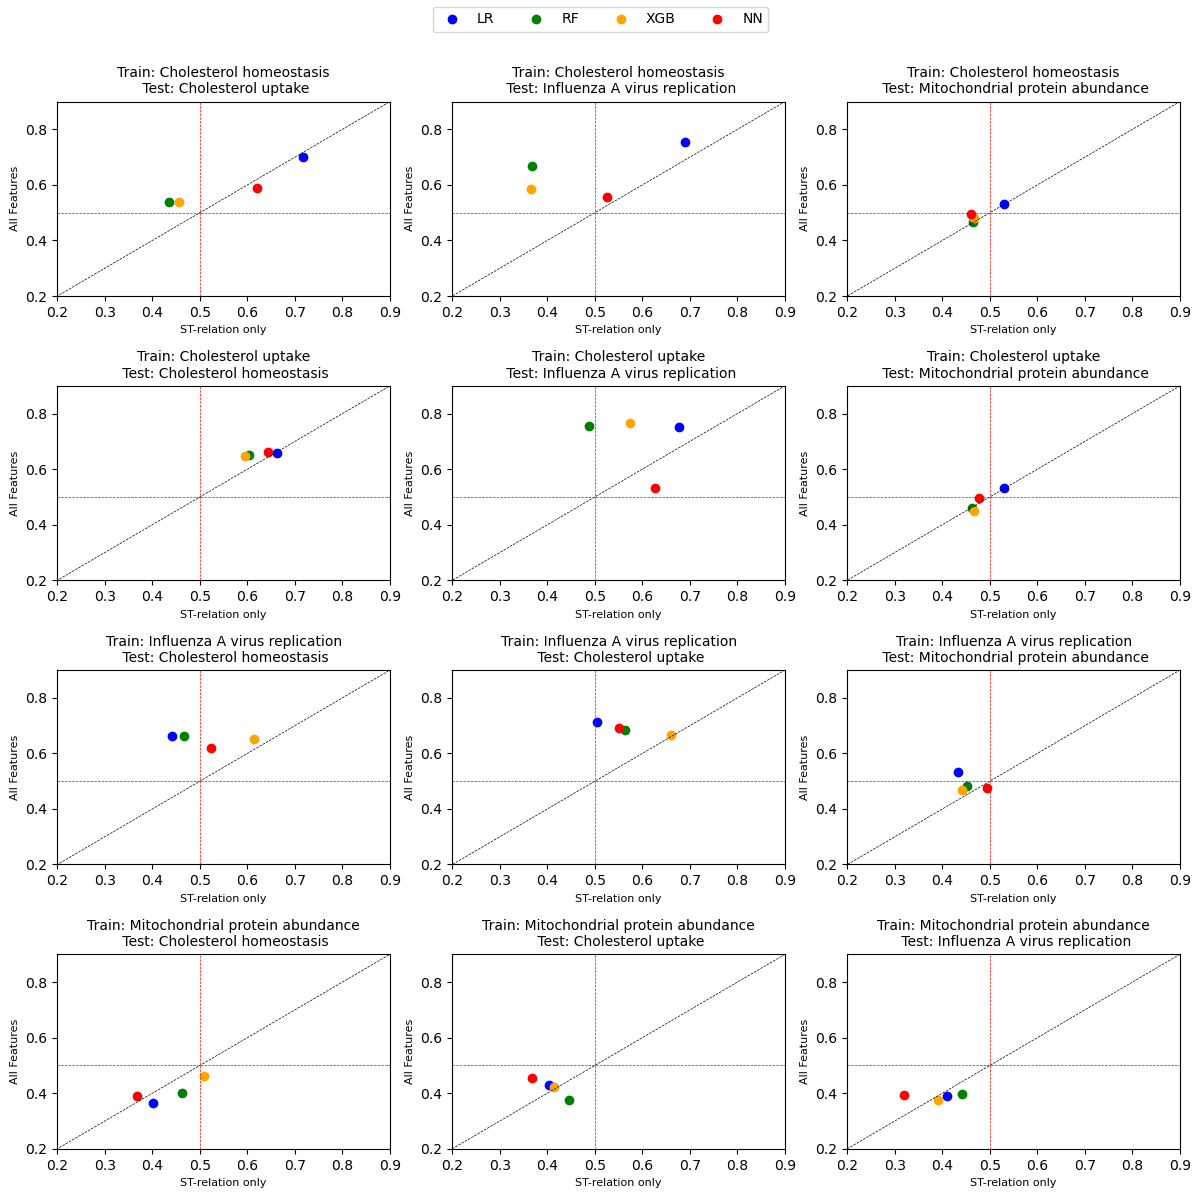

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define phenotype lists
train_phenos = lr_all_feature_auc_df.index
test_phenos = lr_all_feature_auc_df.columns

# Layout for subplots
n_plots = len(train_phenos) * len(test_phenos)
n_cols = int(np.ceil(np.sqrt(n_plots)))
n_rows = int(np.ceil(n_plots / n_cols))

# Model info
model_names = ['LR', 'RF', 'XGB', 'NN']
model_colors = ['blue', 'green', 'orange', 'red']

# Create subplots
fig, axes = plt.subplots(4,3, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

plot_idx = 0
for train_pheno in train_phenos:
    for test_pheno in test_phenos:
        test_name = test_pheno.replace('\n','')
        if train_pheno != test_name:
            print(train_pheno,test_name)
            # ppi_only_auroc = [
            #     lr_ppi_only_auc_df.loc[train_pheno, test_pheno],
            #     rf_ppi_only_auc_df.loc[train_pheno, test_pheno],
            #     xgb_ppi_only_auc_df.loc[train_pheno, test_pheno],
            #     nn_ppi_only_auc_df.loc[train_pheno, test_pheno]
            # ]
            st_relation_auroc = [
                lr_st_relation_auc_df.loc[train_pheno, test_pheno],
                rf_st_relation_auc_df.loc[train_pheno, test_pheno],
                xgb_st_relation_auc_df.loc[train_pheno, test_pheno],
                nn_st_relation_auc_df.loc[train_pheno, test_pheno]
            ]
            all_feature_auroc = [
                lr_all_feature_auc_df.loc[train_pheno, test_pheno],
                rf_all_feature_auc_df.loc[train_pheno, test_pheno],
                xgb_all_feature_auc_df.loc[train_pheno, test_pheno],
                nn_all_feature_auc_df.loc[train_pheno, test_pheno]
            ]
            ax = axes[plot_idx]
            # Plot each model as a colored dot
            for i in range(len(model_names)):
                # ax.scatter(ppi_only_auroc[i], all_feature_auroc[i],
                #         color=model_colors[i], label=model_names[i])
                ax.scatter(st_relation_auroc[i], all_feature_auroc[i],
                        color=model_colors[i], label=model_names[i])

            # Diagonal reference
            ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
            ax.axhline(y=0.5, color='r', linestyle='--', linewidth=0.5)
            ax.axvline(x=0.5, color='r', linestyle='--', linewidth=0.5)
            test_pheno = test_pheno.replace('\n','')
            ax.set_title(f'Train: {train_pheno}\n Test: {test_pheno}', fontsize=10)
            ax.set_xlim(0.2, 0.9)
            ax.set_ylim(0.2, 0.9)
            # ax.set_xlabel('PPI feature only', fontsize=8)
            ax.set_xlabel('ST-relation only', fontsize=8)
            ax.set_ylabel('All Features', fontsize=8)
            plot_idx += 1

# Remove unused axes
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

# Shared legend
handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                      color=model_colors[i], label=model_names[i])
           for i in range(len(model_names))]
fig.legend(handles=handles, loc='upper center', ncol=4)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
#plt.savefig('/Users/leojin/Desktop/IGVF/Plot/Transfer/Transfer_comparison.pdf',dpi = 800)


### Bar plots

In [5]:
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

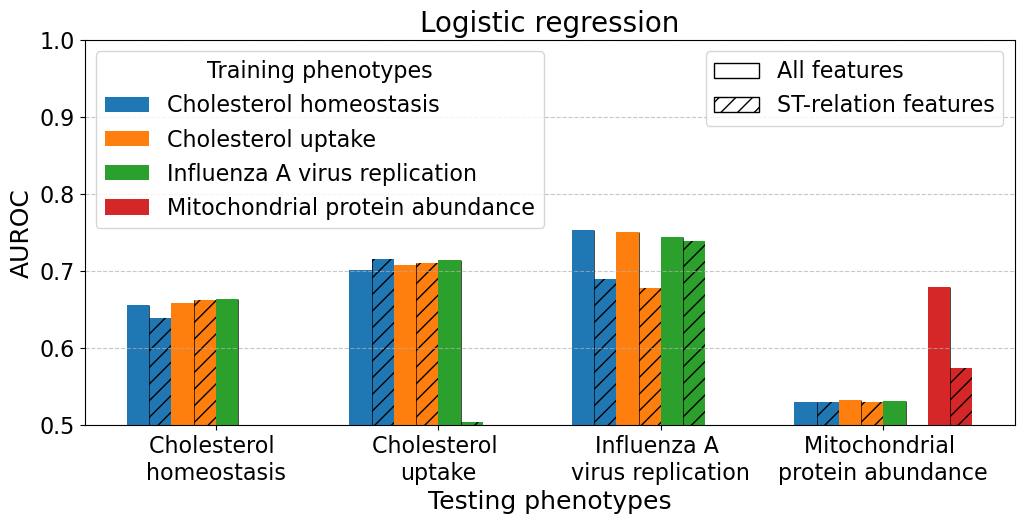

In [ ]:
df1 = lr_all_feature_auc_df.T
# df2 = lr_ppi_only_auc_df.T
df2 = lr_st_relation_auc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
bars = list()
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    bar1 = plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    bar2 = plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUROC',fontsize = 18)
plt.title('Logistic regression',fontsize = 20)
plt.ylim((0.5,1))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)


ax = plt.gca()
training_handles = [Patch(facecolor=colors[i]) for i in range(len(df2.columns))]
legend_train = ax.legend(training_handles, list(df2.columns),
                         title='Training phenotypes', loc='upper left',
                         fontsize=16, title_fontsize=16)
feature_handles = [
    Patch(facecolor='white', edgecolor='black', label='All features'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='ST-relation features')
]
legend_feat = ax.legend(feature_handles, ['All features', 'ST-relation features'],
                        loc='upper right',fontsize=16, title_fontsize=16)
ax.add_artist(legend_train)
#plt.savefig('../Plot/Transfer_tuned/Transfer_AUROC_LogisticRegression.png',dpi = 800,bbox_inches='tight')

plt.show()

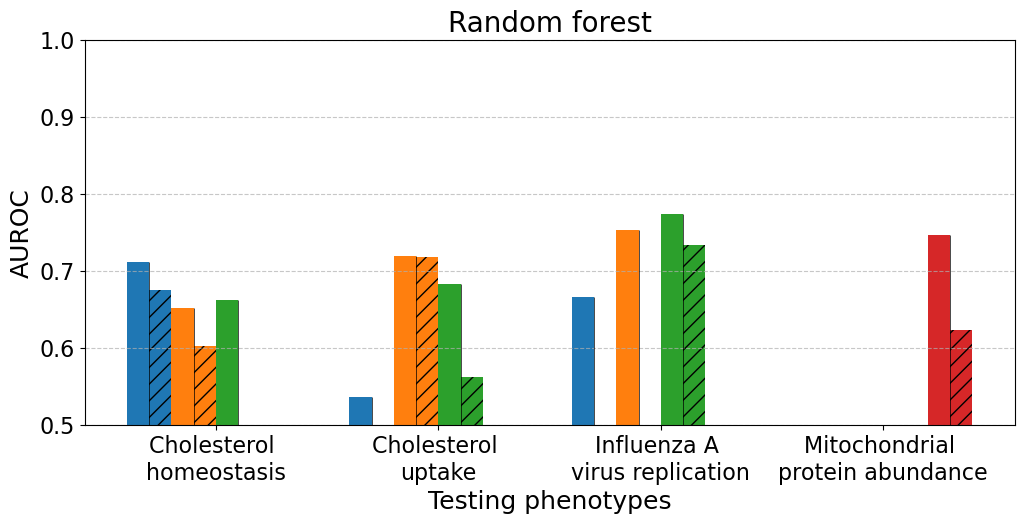

In [ ]:
df1 = rf_all_feature_auc_df.T
# df2 = rf_ppi_only_auc_df.T
df2 = rf_st_relation_auc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUROC',fontsize = 18)
plt.title('Random forest',fontsize = 20)
plt.ylim((0.5,1))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)
#plt.savefig('../Plot/Transfer_tuned/Transfer_AUROC_RandomForest.png',dpi = 800,bbox_inches='tight')
plt.show()


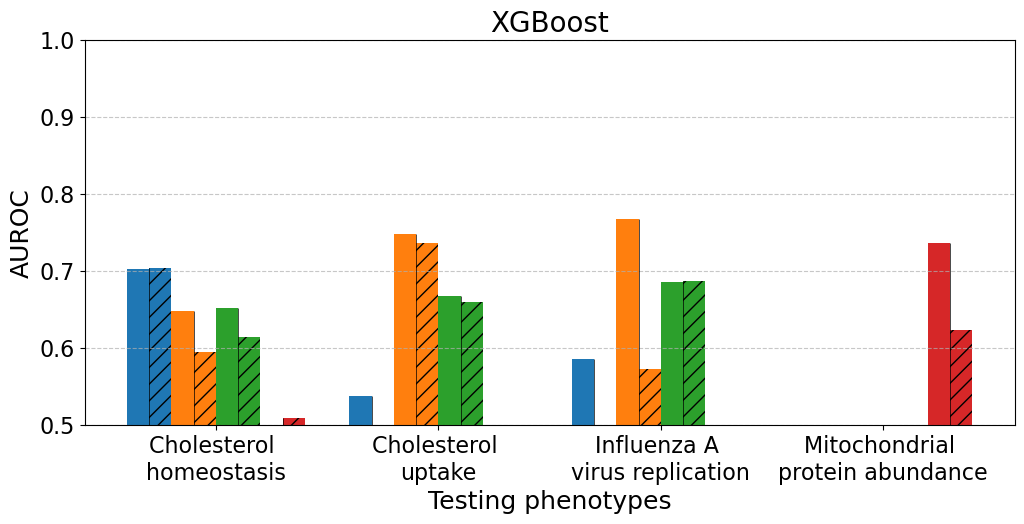

In [ ]:
df1 = xgb_all_feature_auc_df.T
# df2 = xgb_ppi_only_auc_df.T
df2 = xgb_st_relation_auc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUROC',fontsize = 18)
plt.title('XGBoost',fontsize = 20)
plt.ylim((0.5,1))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)
# plt.savefig('../Plot/Transfer_tuned/Transfer_AUROC_XGBoost.png',dpi = 800,bbox_inches='tight')
plt.show()

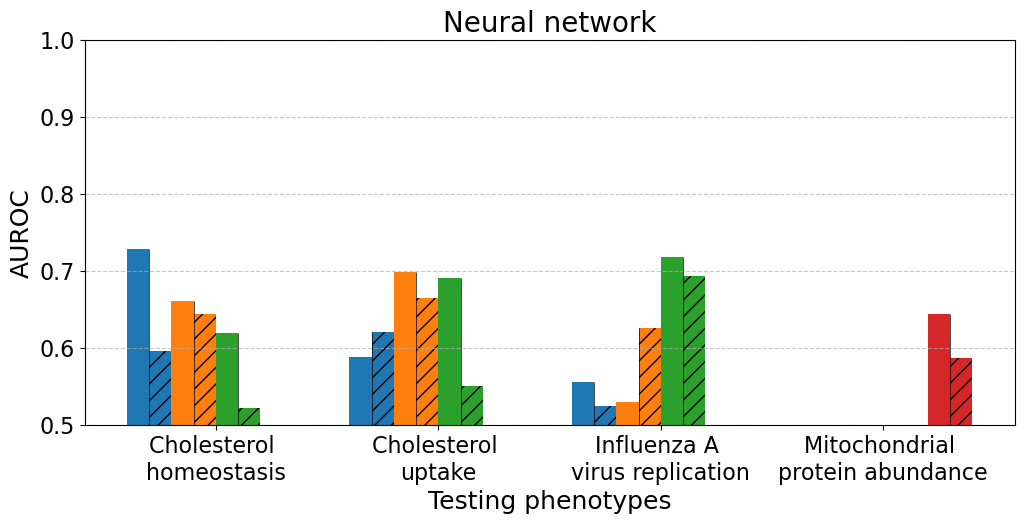

In [ ]:
df1 = nn_all_feature_auc_df.T
# df2 = nn_ppi_only_auc_df.T
df2 = nn_st_relation_auc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUROC',fontsize = 18)
plt.title('Neural network',fontsize = 20)
plt.ylim((0.5,1))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)
# plt.savefig('../Plot/Transfer_tuned/Transfer_AUROC_NN.png',dpi = 800,bbox_inches='tight')
plt.show()

### Precision-Recall

In [11]:
method = 'LogisticRegression'
lr_ppi_only_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_ppi_only.csv',index_col=0)
lr_st_relation_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_st_relation.csv',index_col=0)
lr_all_feature_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_all_features.csv',index_col = 0)
method = 'RandomForest'
rf_ppi_only_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_ppi_only.csv',index_col=0)
rf_st_relation_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_st_relation.csv',index_col=0)
rf_all_feature_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_all_features.csv',index_col = 0)
method = 'XGBoost'
xgb_ppi_only_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_ppi_only.csv',index_col=0)
xgb_st_relation_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_st_relation.csv',index_col=0)
xgb_all_feature_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_all_features.csv',index_col = 0)
method = 'NN'
nn_ppi_only_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_ppi_only.csv',index_col=0)
nn_st_relation_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_st_relation.csv',index_col=0)
nn_all_feature_prc_df = pd.read_csv('../Plot/Transfer_tuned/Transfer_AUPRC_'+method+'_all_features.csv',index_col = 0)



In [12]:
LDLR_dataset = pd.read_csv('../Data/LDLR/train_node_attribute_LDLR_with_target_feature.csv')
SREBP2_dataset = pd.read_csv('../Data/SREBP2/train_node_attribute_SREBP2_with_target_feature.csv')
Influenza_dataset = pd.read_csv('../Data/Influenza/train_node_attribute_Influenza_with_target_feature.csv')
Mitomics_dataset = pd.read_csv('../Data/Mitomics/train_node_attribute_Mitomics_with_target_feature.csv')
LDLR_baseline = LDLR_dataset['label'].sum()/len(LDLR_dataset)
SREBP2_baseline = SREBP2_dataset['label'].sum()/len(SREBP2_dataset)
Influenza_baseline = Influenza_dataset['label'].sum()/len(Influenza_dataset)
Mitomics_baseline = Mitomics_dataset['label'].sum()/len(Mitomics_dataset)
baselines = [LDLR_baseline,SREBP2_baseline,Influenza_baseline,Mitomics_baseline]

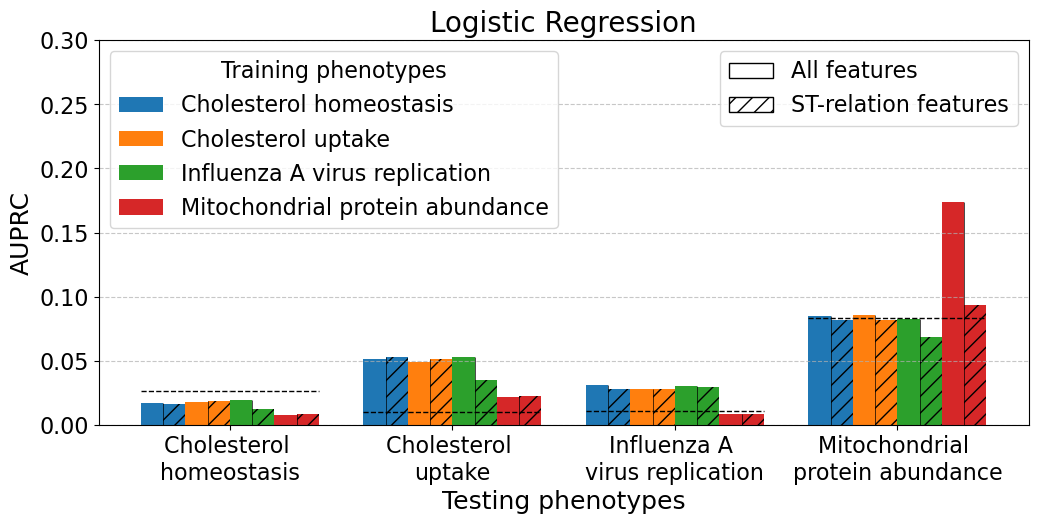

In [13]:
df1 = lr_all_feature_prc_df.T
# df2 = lr_ppi_only_prc_df.T
df2 = lr_st_relation_prc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
    for j in range(len(baselines)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baselines[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=1)    
        
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUPRC',fontsize = 18)
plt.title('Logistic Regression',fontsize = 20)
plt.ylim((0,0.3))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)


ax = plt.gca()
training_handles = [Patch(facecolor=colors[i]) for i in range(len(df2.columns))]
legend_train = ax.legend(training_handles, list(df2.columns),
                         title='Training phenotypes', loc='upper left',
                         fontsize=16, title_fontsize=16)
feature_handles = [
    Patch(facecolor='white', edgecolor='black', label='All features'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='ST-relation features')
]
legend_feat = ax.legend(feature_handles, ['All features', 'ST-relation features'],
                        loc='upper right',fontsize=16, title_fontsize=16)
ax.add_artist(legend_train)
# plt.savefig('../Plot/Transfer_tuned/Transfer_AUPRC_LogisticRegression.png',dpi = 800,bbox_inches='tight')
plt.show()

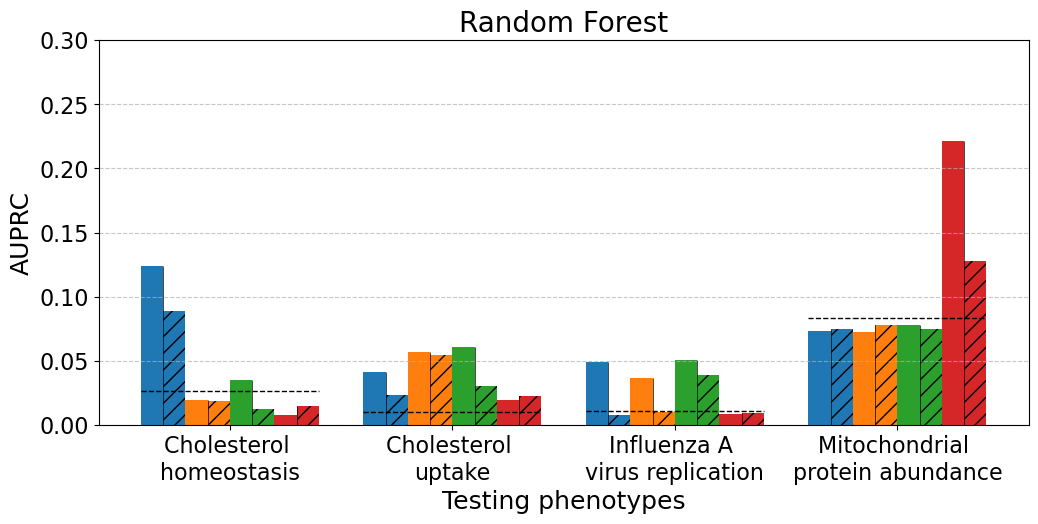

In [14]:
df1 = rf_all_feature_prc_df.T
# df2 = rf_ppi_only_prc_df.T
df2 = rf_st_relation_prc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
    for j in range(len(baselines)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baselines[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=1)    
        
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUPRC',fontsize = 18)
plt.title('Random Forest',fontsize = 20)
plt.ylim((0,0.3))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)
# plt.savefig('../Plot/Transfer_tuned/Transfer_AUPRC_RandomForest.png',dpi = 800,bbox_inches='tight')
plt.show()

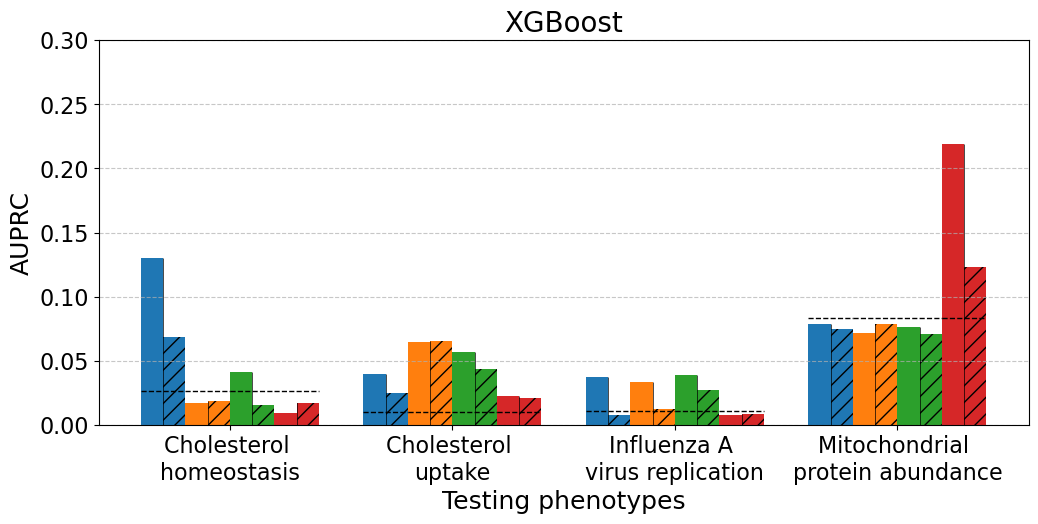

In [15]:
df1 = xgb_all_feature_prc_df.T
# df2 = xgb_ppi_only_prc_df.T
df2 = xgb_st_relation_prc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
    for j in range(len(baselines)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baselines[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=1)    
        
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUPRC',fontsize = 18)
plt.title('XGBoost',fontsize = 20)
plt.ylim((0,0.3))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)
# plt.savefig('../Plot/Transfer_tuned/Transfer_AUPRC_XGBoost.png',dpi = 800,bbox_inches='tight')
plt.show()

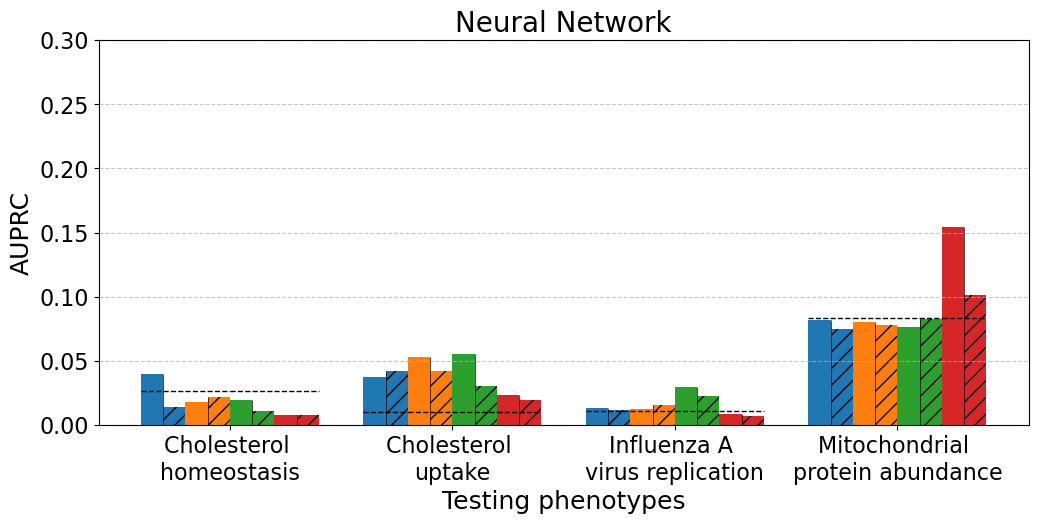

In [16]:
df1 = nn_all_feature_prc_df.T
# df2 = nn_ppi_only_prc_df.T
df2 = nn_st_relation_prc_df.T
# Number of categories (rows) and groups (columns)
categories = df1.index
# df.columns = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
groups = df1.columns
# Bar width and positions for bars
bar_width = 0.2
bar_positions = np.arange(len(categories))
# Create a figure
plt.figure(figsize=(12, 5))
for i, col in enumerate(df2.columns):
    pos = bar_positions + i * bar_width
    # Left half: df1[col]
    plt.bar(pos - bar_width / 4,
            df1[col],
            width=bar_width / 2,
            color=colors[i],
            alpha=1.0,
            label=col)

    # Right half: df2[col]
    plt.bar(pos + bar_width / 4,
            df2[col],
            width=bar_width / 2,
            color=colors[i],
            hatch = '//')
    for j in range(len(df2)):
            x_center = bar_positions[j] + i * bar_width
            height = max(df1[col][j], df2[col][j])
            plt.vlines(x_center, 0, height, color='black', linewidth=0.5)
    for j in range(len(baselines)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baselines[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=1)    
        
# Customize the plot
plt.xlabel('Testing phenotypes',fontsize = 18)
plt.ylabel('AUPRC',fontsize = 18)
plt.title('Neural Network',fontsize = 20)
plt.ylim((0,0.3))
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Training phenotypes',loc = 'upper left',fontsize = 16,title_fontsize = 16)
# plt.savefig('../Plot/Transfer_tuned/Transfer_AUPRC_NN.png',dpi = 800,bbox_inches='tight')
plt.show()